## 시각화 기초

### Matplotlib
> 파이썬 데이터분석에서 가장 많이 사용되는 시각화(차트/그래프) 라이브러리

In [ ]:
# 기본적으로 필요한 패키지 
import pandas as pd
import numpy as np

In [2]:
# 차트용 패키지 
import matplotlib.pyplot as plt
import seaborn as sns

- 한글 출력 문제 해결

In [ ]:
plt.rcParams['font.family'] = 'Malgun gothic' # 한글폰트 설정 
plt.rcParams['axes.unicode_minus'] = False    # utf-8 등 국제어 환경에서 마이너스 기호 깨짐 방지

#### 기본 데이터

In [5]:
data = {
    "order_date": [
        "2026-09-01", "2026-09-01", "2026-09-02", "2026-09-02",
        "2026-09-03", "2026-09-03", "2026-09-04", "2026-09-04",
        "2026-09-05", "2026-09-05"
    ],

    "customer": ["홍길동", "김철수", "이영희", "홍길동", "박민수", "김철수", "최지훈", "이영희", "홍길동", "박민수"],
    "category": ["주변기기", "주변기기", "컴퓨터", "저장장치", "주변기기", "저장장치", "컴퓨터", "주변기기", "저장장치", "컴퓨터"],
    "product": ["키보드", "마우스", "노트북", "USB", "마우스", "USB", "노트북", "키보드", "SSD", "모니터"],
    "quantity": [2, 1, 1, 5, 3, 4, 1, 2, 1, 1],
    "unit_price": [30000, 15000, 1200000, 12000, 15000, 12000, 1200000, 30000, 90000, 250000]
}


In [8]:
df =pd.DataFrame(data)
df

,order_date,customer,category,product,quantity,unit_price
0,2026-09-01,홍길동,주변기기,키보드,2,30000
1,2026-09-01,김철수,주변기기,마우스,1,15000
2,2026-09-02,이영희,컴퓨터,노트북,1,1200000
3,2026-09-02,홍길동,저장장치,USB,5,12000
4,2026-09-03,박민수,주변기기,마우스,3,15000
5,2026-09-03,김철수,저장장치,USB,4,12000
6,2026-09-04,최지훈,컴퓨터,노트북,1,1200000
7,2026-09-04,이영희,주변기기,키보드,2,30000
8,2026-09-05,홍길동,저장장치,SSD,1,90000
9,2026-09-05,박민수,컴퓨터,모니터,1,250000


In [9]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [10]:
df['total_price'] = df['quantity'] * df['unit_price']

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_date   10 non-null     datetime64[us]
 1   customer     10 non-null     str           
 2   category     10 non-null     str           
 3   product      10 non-null     str           
 4   quantity     10 non-null     int64         
 5   unit_price   10 non-null     int64         
 6   total_price  10 non-null     int64         
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 692.0 bytes


#### 결측치나 이상치 제거 필요
- 현재 데이터에는 없음

In [ ]:
# 판다스로 볼 수 있는 기본통계
df.describe()

,order_date,quantity,unit_price,total_price
count,10,10.000000,1.000000e+01,1.000000e+01
mean,2026-09-03 00:00:00,2.100000,2.854000e+05,3.028000e+05
min,2026-09-01 00:00:00,1.000000,1.200000e+04,1.500000e+04
25%,2026-09-02 00:00:00,1.000000,1.500000e+04,5.100000e+04
50%,2026-09-03 00:00:00,1.500000,3.000000e+04,6.000000e+04
75%,2026-09-04 00:00:00,2.750000,2.100000e+05,2.100000e+05
max,2026-09-05 00:00:00,5.000000,1.200000e+06,1.200000e+06
std,NaN,1.449138,4.874658e+05,4.771531e+05


In [14]:
# 카테고리별 데이터 확인
df['category'].unique()

<StringArray>
['주변기기', '컴퓨터', '저장장치']
Length: 3, dtype: str

In [15]:
df['product'].unique()

<StringArray>
['키보드', '마우스', '노트북', 'USB', 'SSD', '모니터']
Length: 6, dtype: str

In [16]:
df['customer'].unique()

<StringArray>
['홍길동', '김철수', '이영희', '박민수', '최지훈']
Length: 5, dtype: str

In [17]:
df['order_date'].unique()

<DatetimeArray>
['2026-09-01 00:00:00', '2026-09-02 00:00:00', '2026-09-03 00:00:00',
 '2026-09-04 00:00:00', '2026-09-05 00:00:00']
Length: 5, dtype: datetime64[us]

In [18]:
df['category'].value_counts()

category
주변기기    4
컴퓨터     3
저장장치    3
Name: count, dtype: int64

#### Matplotlib 기본사용법

##### 선 그래프

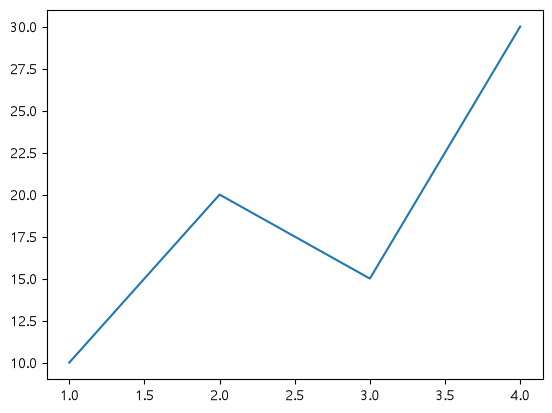

In [19]:
plt.figure()
plt.plot([1,2,3,4],[10,20,15,30])
plt.show()

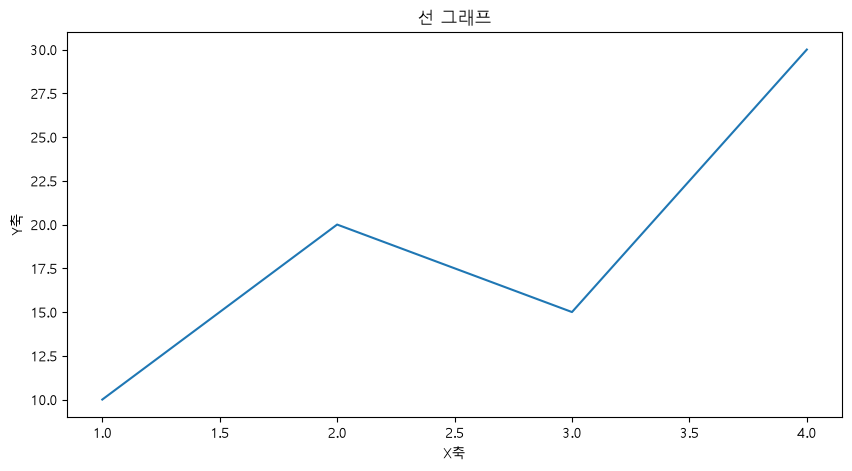

In [23]:
plt.figure(figsize=(10,5))          #figure size = (그래프 넓이, 그래프 높이)
plt.plot([1,2,3,4],[10,20,15,30])   #plot(x축 데이터, y축 데이터)
plt.title('선 그래프')               #그래프 제목
plt.xlabel('X축')                    #x축 제목
plt.ylabel('Y축')                    #y축 제목
plt.show()

##### Seaborn 패키지
> Matplotlib을 좀 더 예쁘게 출력을 지원
- Seaborn용 추가 차트 기능도 존재

In [24]:
sns.set_theme(style='darkgrid', font='Malgun Gothic')

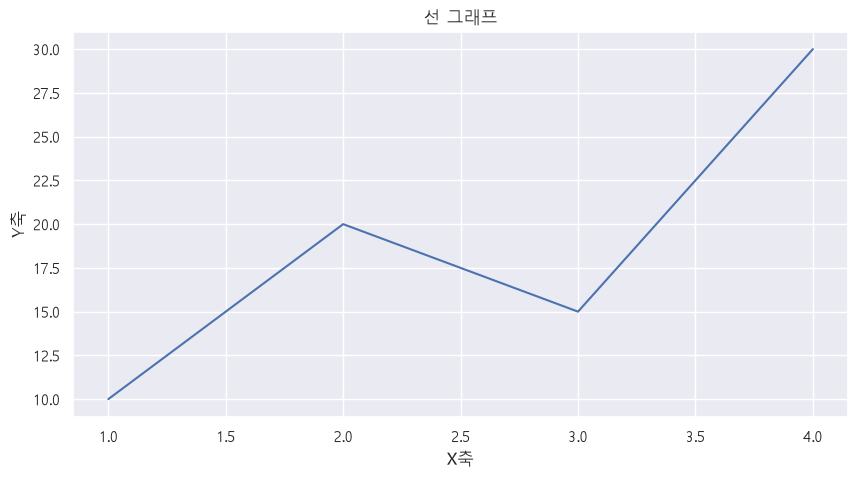

In [25]:
plt.figure(figsize=(10,5))         
plt.plot([1,2,3,4],[10,20,15,30])  
plt.title('선 그래프')             
plt.xlabel('X축')                 
plt.ylabel('Y축')                   
plt.show()

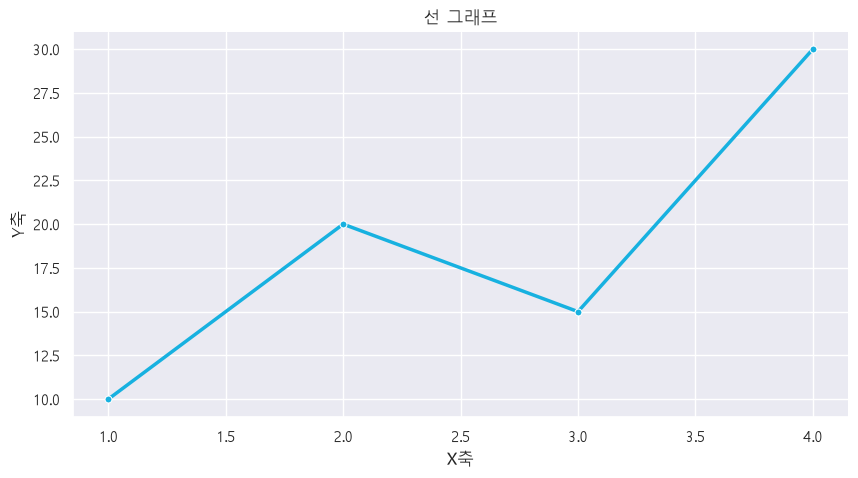

In [28]:
plt.figure(figsize=(10,5))         
# plt.plot([1,2,3,4],[10,20,15,30])  

sns.lineplot(
    x=[1,2,3,4], 
    y=[10,20,15,30],
    marker='o',
    markersize=5,
    linewidth=2.5,
    color="#17B1E0"
    )

plt.title('선 그래프')             
plt.xlabel('X축')                 
plt.ylabel('Y축')         

sns.despine() # 그래프 테투리 제거
plt.show()

##### 막대 그래프
- 항목별(카테고리) 크기를 비교할때 사용

In [32]:
df.groupby('category')['total_price'].sum().reset_index()

,category,total_price
0,저장장치,198000
1,주변기기,180000
2,컴퓨터,2650000


In [33]:
cate_sales = df.groupby('category')['total_price'].sum().reset_index()

In [34]:
cate_sales['category']

0    저장장치
1    주변기기
2     컴퓨터
Name: category, dtype: str

In [35]:
cate_sales['total_price']

0     198000
1     180000
2    2650000
Name: total_price, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

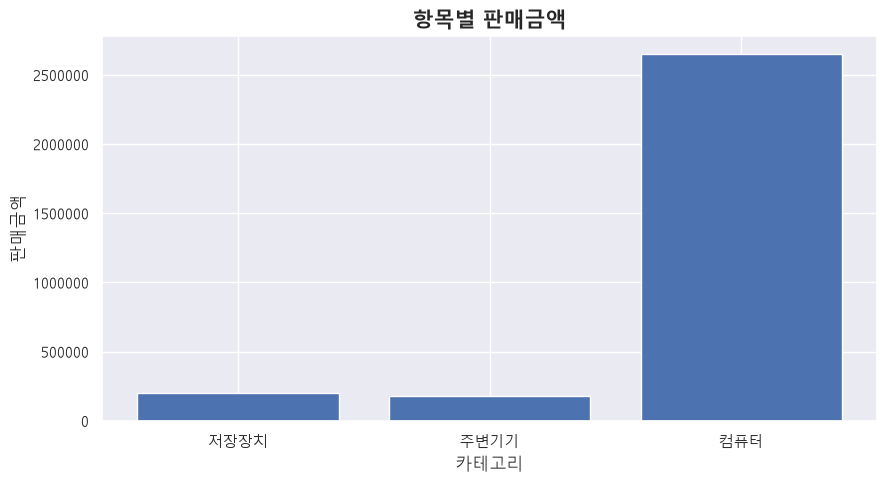

In [47]:
plt.figure(figsize=(10, 5))
# 막대그래프 plt.bar()
plt.bar(x= cate_sales['category'], height=cate_sales['total_price'])
plt.title('항목별 판매금액', fontsize=15, fontweight='bold')
plt.xlabel('카테고리')
plt.ylabel('판매금액')

plt.ticklabel_format(style='plain', axis='y') # Y축은 판매금액 그대로 출력. 2.5 1e6
plt.show

#### 선 그래프
- 날짜별 매출 계산

In [49]:
df.groupby('order_date')['total_price'].sum().reset_index()

,order_date,total_price
0,2026-09-01,75000
1,2026-09-02,1260000
2,2026-09-03,93000
3,2026-09-04,1260000
4,2026-09-05,340000


In [51]:
daily_sales = df.groupby('order_date')['total_price'].sum().reset_index()

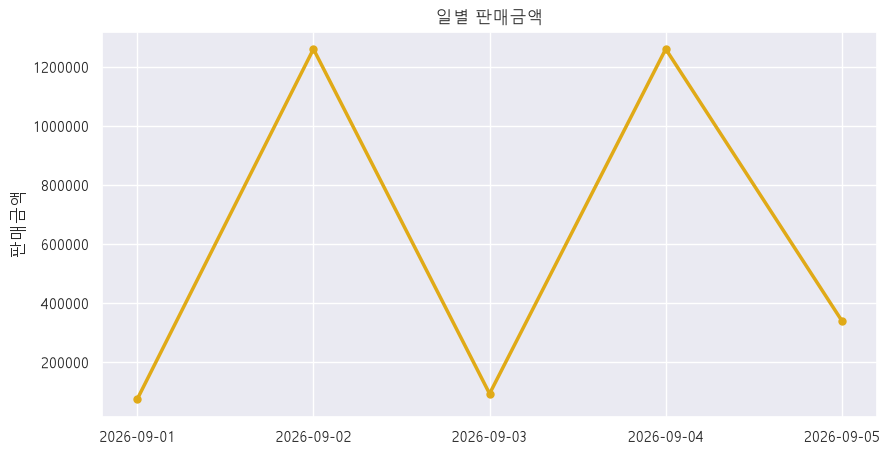

In [63]:
plt.figure(figsize=(10, 5))
plt.plot(daily_sales['order_date'], 
         daily_sales['total_price'], 
         marker='o',
         markersize=5, 
         linewidth=2.5, 
         color="#E0AA17")

plt.title('일별 판매금액')
plt.ylabel('판매금액')
plt.ticklabel_format(style='plain', axis='y')

# 실제 데이터가 있는 위치의 x축 레이블만 표시
plt.xticks(
    daily_sales['order_date'],
    daily_sales['order_date'].dt.strftime('%Y-%m-%d') # df.strtime 대신 .to.string(%y-%m-%d') 사용가능 시간표시없이 날짜변환
)

plt.show()

##### 히스토그램
> 표준편차, 분포와 관계있는 그래프 
- 숫자 데이터의 분포를 확인할때 사용

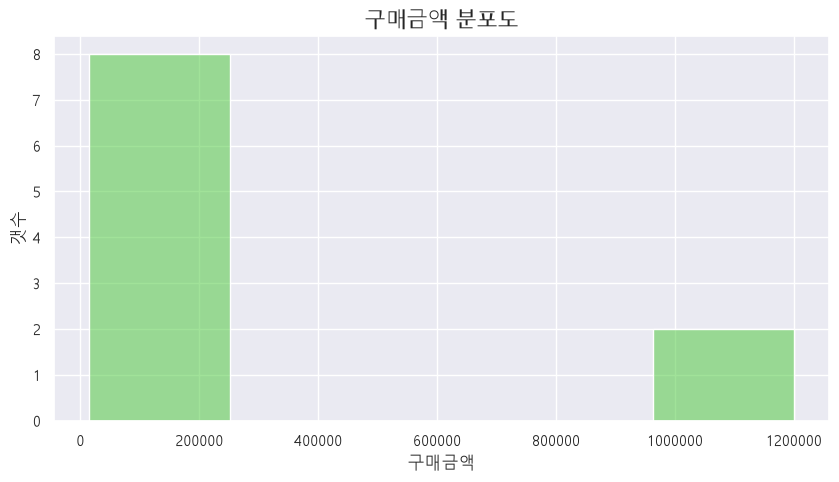

In [100]:
plt.figure(figsize=(10, 5))
# 히스토그램

plt.hist(df['total_price'], bins=5, color="#50CA4088")  # bins 구간갯수
plt.title('구매금액 분포도', fontsize=15)
plt.xlabel('구매금액')
plt.ylabel('갯수')

plt.ticklabel_format(style='plain', axis='x')
plt.show()

##### 산점도
> 두 숫자 데이터간의 관계를 확인하는 그래프
- 데이터 분석시 가장 많이 사용

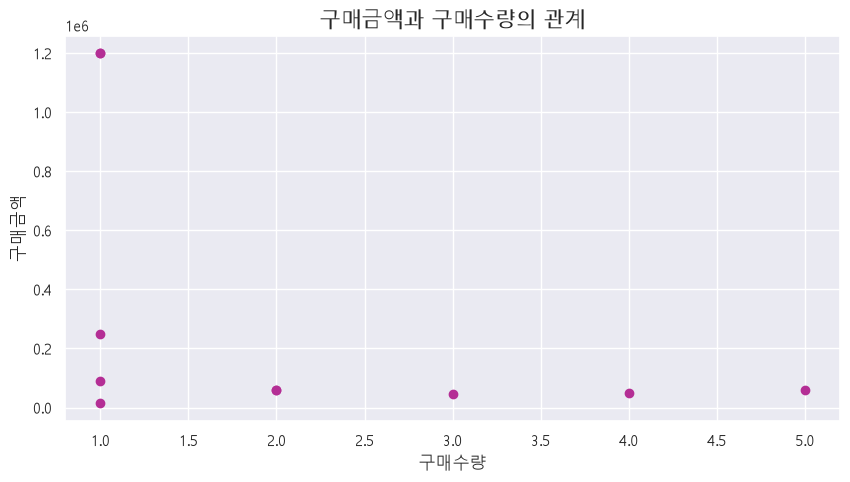

In [81]:
plt.figure(figsize=(10, 5))

# 산점도
plt.scatter(x=df['quantity'], y=df['total_price'], color="#B42E95")
plt.title('구매금액과 구매수량의 관계' , fontsize=15)
plt.xlabel('구매수량')
plt.ylabel('구매금액')

plt.show()

##### 박스플롯
> 데이터의 이상치와 분포를 같이 확인할때 사용

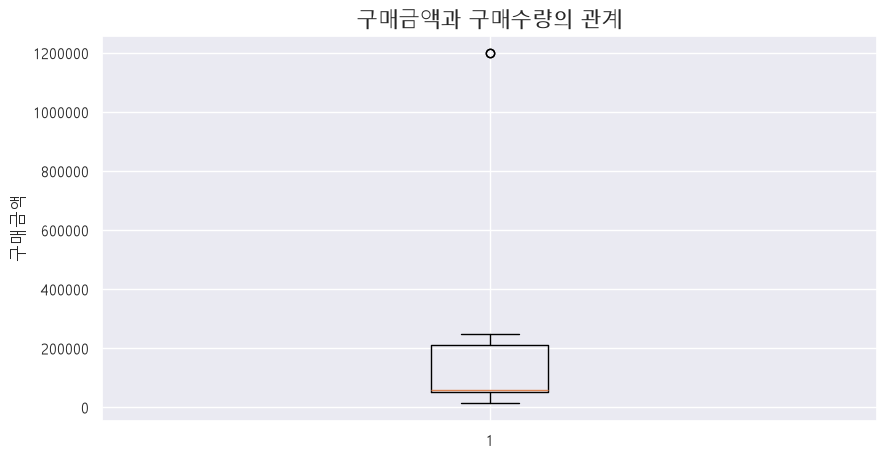

In [97]:
plt.figure(figsize=(10, 5))

# 박스플롯
plt.boxplot(df['total_price'])
plt.title('구매금액과 구매수량의 관계' , fontsize=15)

plt.ylabel('구매금액')

plt.ticklabel_format(style='plain', axis='y')
plt.show()

##### 선 그래프 마커위치에 데이터 표시

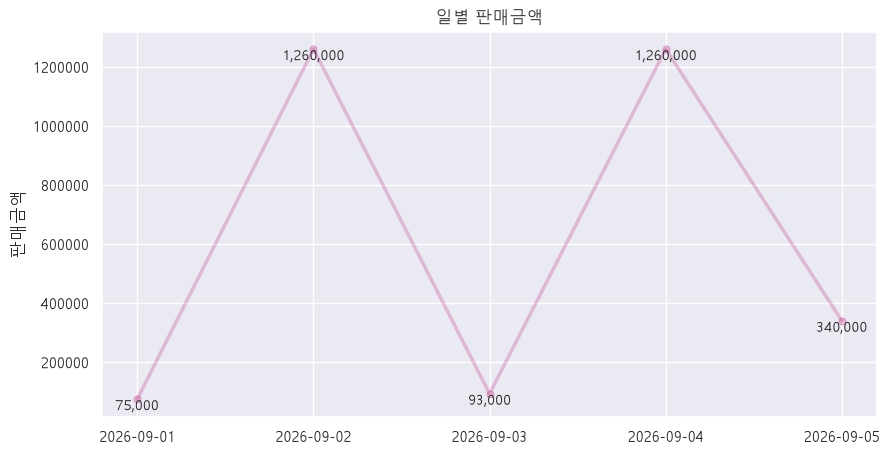

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(daily_sales['order_date'], 
         daily_sales['total_price'], 
         marker='o',
         markersize=5, 
         linewidth=2.5, 
         color="#BE207C40")

# 마커위치에 실제 데이터 표시
for x, y in zip(daily_sales['order_date'], daily_sales['total_price']):
    plt.text(
        x, y,
        f"{y:,}",     # y값 = 금액
        ha='center',  # 가로축 정렬 left, right - 정렬 이름 반대
        va='top',     # 세로축 정렬 top, bottom - 정렬 이름 반대
        fontsize=10     
    
    )

plt.title('일별 판매금액')
plt.ylabel('판매금액')
plt.ticklabel_format(style='plain', axis='y')

# 실제 데이터가 있는 위치의 x축 레이블만 표시
plt.xticks(
    daily_sales['order_date'],
    daily_sales['order_date'].dt.strftime('%Y-%m-%d') # df.strtime 대신 .to.string(%y-%m-%d') 사용가능 시간표시없이 날짜변환
)

plt.show()

#### Seaborn으로 손쉽게 차트 구현
> Matplotlib은 판다스 DF를 바로 사용못함. Seaborn은 DF를 매개변수로 활용가능
- Matplotlib은 x, y(height) 값을 시리즈로 만들어서 전달
- Seaborn은 데이터프레임 그대로 data 속성에 전달

<function matplotlib.pyplot.show(close=None, block=None)>

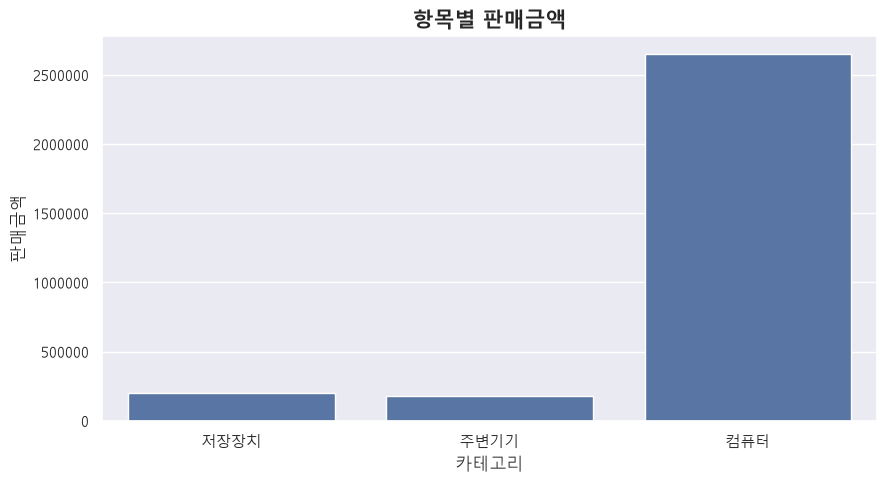

In [98]:
plt.figure(figsize=(10, 5))

# 막대그래프 plt.bar() -> Seaborn barplot()으로 변경
sns.barplot(data=cate_sales, x='category', y='total_price')

plt.title('항목별 판매금액', fontsize=15, fontweight='bold')
plt.xlabel('카테고리')
plt.ylabel('판매금액')

plt.ticklabel_format(style='plain', axis='y') 
plt.show

##### Seaborn Heatmap
> 숫자 데이터 분포를 색상으로 표현하는 그래프

In [102]:
# 구매수량, 단가, 구매금액 간의 상관관계
df[['quantity', 'unit_price', 'total_price']]

,quantity,unit_price,total_price
0,2,30000,60000
1,1,15000,15000
2,1,1200000,1200000
3,5,12000,60000
4,3,15000,45000
5,4,12000,48000
6,1,1200000,1200000
7,2,30000,60000
8,1,90000,90000
9,1,250000,250000


In [103]:
corr = df[['quantity', 'unit_price', 'total_price']].corr()

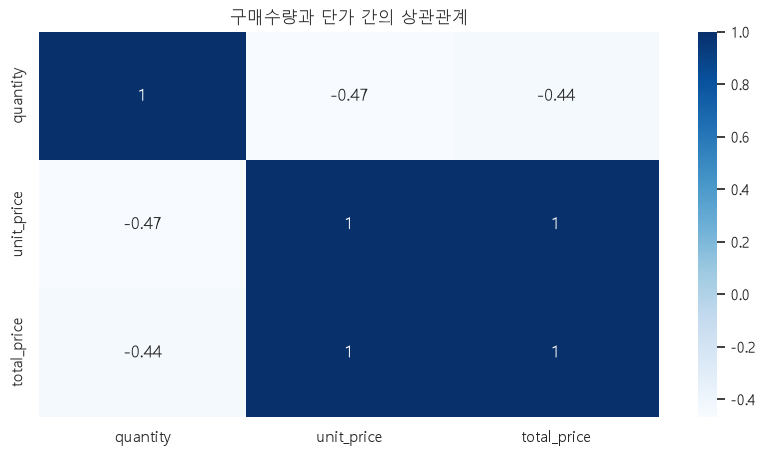

In [104]:
plt.figure(figsize=(10, 5))
# 히트맵으로 변경
sns.heatmap(data=corr, annot=True, cmap='Blues')

plt.title('구매수량과 단가 간의 상관관계')

plt.show()